## Examples

Let's talk through some basic examples showing how AI systems can appear to perform well in controlled experiments but exhibit poor performance in the real world.

### Example 1: Trusting Correlation

Sometimes two features appear to be uncorrelated but are really strongly related. Other times, two features appear to be highly correlated but are really unrelated.

When might this be a problem?

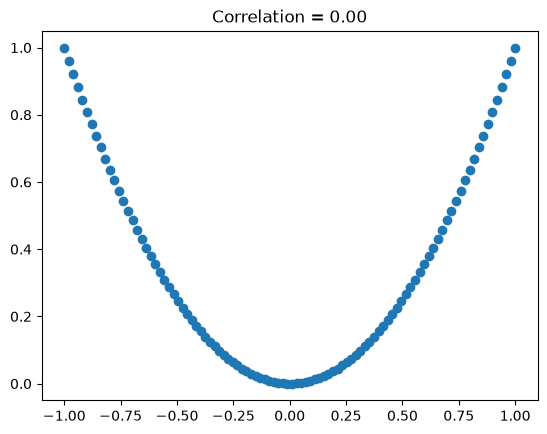

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-1, 1, 100)
y = x**2

plt.scatter(x, y)
plt.title(f"Correlation = {np.corrcoef(x, y)[0, 1]:.2f}")
plt.show()

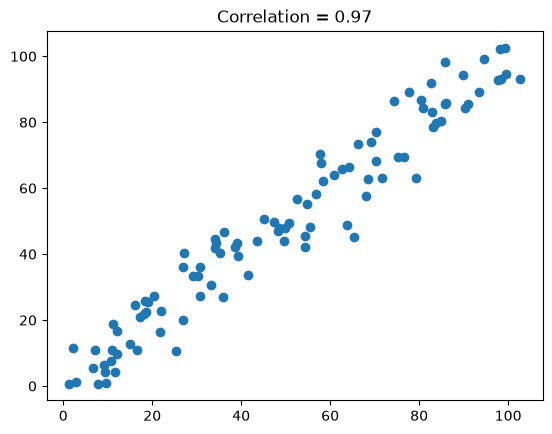

In [2]:
t = np.arange(100)
x = t + np.random.randn(100) * 5
y = t + np.random.randn(100) * 5

plt.scatter(x, y)
plt.title(f"Correlation = {np.corrcoef(x, y)[0, 1]:.2f}")
plt.show()

### Example 2: Poor Software Hygiene

Sometimes sneaky bugs in our code lead us to believe that our system will perform much better than it really does.

Good software practices can mitigate this risk and will be a theme in this course.

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)

X_leaky = X.copy()
X_leaky[:, 0] = y  # sneaky bug: target accidentally copied into a feature

X_train, X_test, y_train, y_test = train_test_split(
    X_leaky, y, test_size=0.3, random_state=0
)

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

print("Test accuracy:", model.score(X_test, y_test))

Test accuracy: 0.9941520467836257


### Example 3: Data Drift

Real world data is constantly changing. Often models perform well initially, but the data distribution changes over time, leading to poor performance.

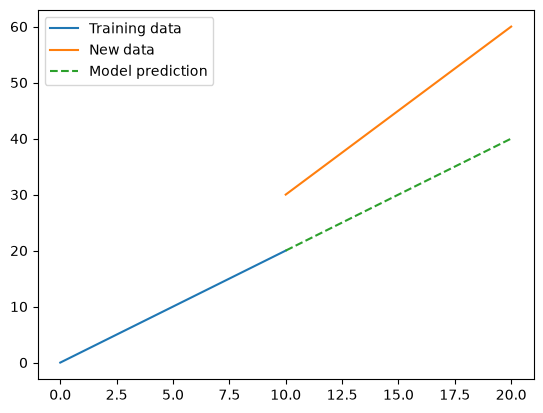

In [4]:
from sklearn.linear_model import LinearRegression

x_train = np.linspace(0, 10, 50)
y_train = 2 * x_train

model = LinearRegression().fit(x_train[:, None], y_train)

x_new = np.linspace(10, 20, 50)
y_new = 3 * x_new

plt.plot(x_train, y_train, label="Training data")
plt.plot(x_new, y_new, label="New data")
plt.plot(x_new, model.predict(x_new[:, None]), "--", label="Model prediction")
plt.legend()
plt.show()

### Example 4: Noisy Data

Noise in the data is often one of the biggest factors that can hurt model performance in the real world. Sometimes models can be trained on noisy data to increase robustness. Other times, noise can be detected and model decisions can be thrown out if unreliable.

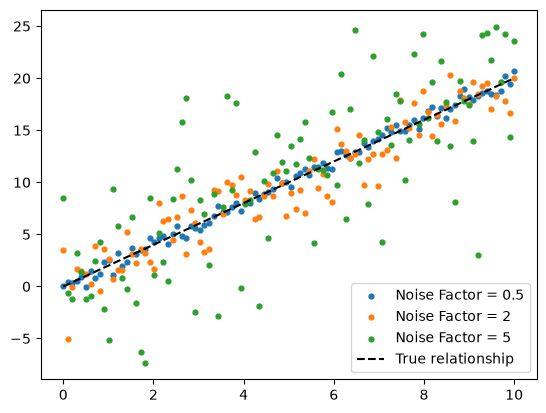

In [5]:
x = np.linspace(0, 10, 100)

for noise in [0.5, 2, 5]:
    y = 2 * x + np.random.randn(100) * noise
    plt.scatter(x, y, label=f"Noise Factor = {noise}", s=12)

plt.plot(x, 2 * x, "k--", label="True relationship")
plt.legend()
plt.show()

### Example 5: The Veterinary Dentists Rule

Often in machine learning there is temptation to apply models to specialized tasks in specialized fields without consideration for problems that will affect model performance that might only be obvious to those with a specialty in those fields! Such problems may have been obvious to experts in the specialized field of application but likely would go unnoticed by engineers with a typical machine learning background.

To ensure ML models perform well on real-world tasks, we need to leverage expertise in ML *and* in the domain of application.

In this class, we will call this the Veterinary Dentists rule. The contrived example below illustrates why domain knowledge might be required to fit a correct model.

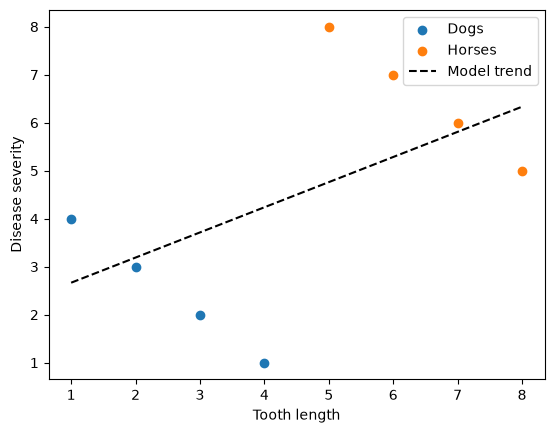

In [6]:
dog_x_tooth_length, dog_y_disease_severity = [1, 2, 3, 4], [4, 3, 2, 1]
horse_x_tooth_length, horse_y_disease_severity = [5, 6, 7, 8], [8, 7, 6, 5]

plt.scatter(dog_x_tooth_length, dog_y_disease_severity, label="Dogs")
plt.scatter(horse_x_tooth_length, horse_y_disease_severity, label="Horses")

x = dog_x_tooth_length + horse_x_tooth_length
y = dog_y_disease_severity + horse_y_disease_severity
plt.plot(x, np.polyval(np.polyfit(x, y, 1), x), "k--", label="Model trend")

plt.xlabel("Tooth length")
plt.ylabel("Disease severity")
plt.legend()
plt.show()

### Example 6: Extrapolation

Even on simple tasks, ML fits are only valid on the domain in which the model was trained. Even advanced ML techniques have difficulty with extrapolation (vs. interpolation, where ML excels) outside their training distributions.

This can even be a problem when applying ML to simple tasks, like fitting mathematical functions. We might be tempted to then conclude that using machine learning tools to approximate mathematical functions is a poor use case, however, there is a rich and useful literature around using machine learning to do just that.

To fix the example below, we need to only realize we should bound our model's input at runtime to the region of input space in which it was trained.

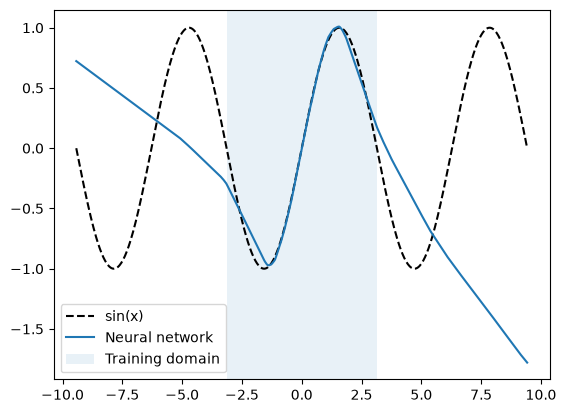

In [7]:
from sklearn.neural_network import MLPRegressor

x = np.linspace(-np.pi, np.pi, 100)
y = np.sin(x)

model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=5000, random_state=0).fit(
    x[:, None], y
)

xx = np.linspace(-3 * np.pi, 3 * np.pi, 500)

plt.plot(xx, np.sin(xx), "k--", label="sin(x)")
plt.plot(xx, model.predict(xx[:, None]), label="Neural network")
plt.axvspan(-np.pi, np.pi, alpha=0.1, label="Training domain")
plt.legend()
plt.show()

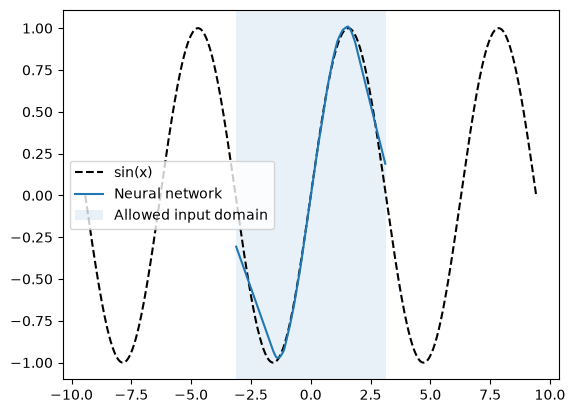

In [8]:
valid = (xx >= x.min()) & (xx <= x.max())

prediction = np.full_like(xx, np.nan)
prediction[valid] = model.predict(xx[valid, None])

plt.plot(xx, np.sin(xx), "k--", label="sin(x)")
plt.plot(xx, prediction, label="Neural network")
plt.axvspan(-np.pi, np.pi, alpha=0.1, label="Allowed input domain")
plt.legend()
plt.show()

### Example 7: Learning the Right Result for the Wrong Reason

One of the most challenging ML pitfalls can be when models learn the correct result fo the wrong reason. For example, an image classifier might learn to classify cars from trucks well. But what if all the images of cars were taken at sunset. Did the classifier learn what a car looked like or learn what the color of the background was?


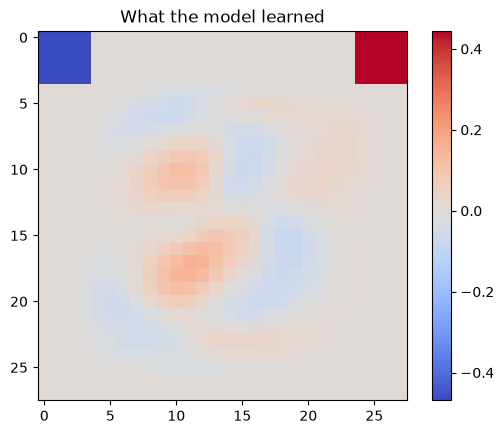

Training accuracy: 1.0
Clean test accuracy: 0.9513363590519415


In [9]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.reshape(-1, 28, 28) / 255
y = y.astype(int)

mask = (y == 3) | (y == 8)
X, y = X[mask], y[mask]

X_train, X_test = X[:10000].copy(), X[10000:].copy()
y_train, y_test = y[:10000], y[10000:]

X_train[y_train == 3, :4, :4] = 1
X_train[y_train == 8, :4, -4:] = 1

model = LogisticRegression(max_iter=1000).fit(
    X_train.reshape(len(X_train), -1), y_train
)

plt.imshow(model.coef_[0].reshape(28, 28), cmap="coolwarm")
plt.colorbar()
plt.title("What the model learned")
plt.show()

print("Training accuracy:", model.score(X_train.reshape(len(X_train), -1), y_train))

print("Clean test accuracy:", model.score(X_test.reshape(len(X_test), -1), y_test))

In [10]:
X_bad = X_test.copy()

X_bad[y_test == 3, :4, -4:] = 1
X_bad[y_test == 8, :4, :4] = 1

print(
    "Accuracy with reversed artifact:",
    model.score(X_bad.reshape(len(X_bad), -1), y_test),
)

Accuracy with reversed artifact: 0.0


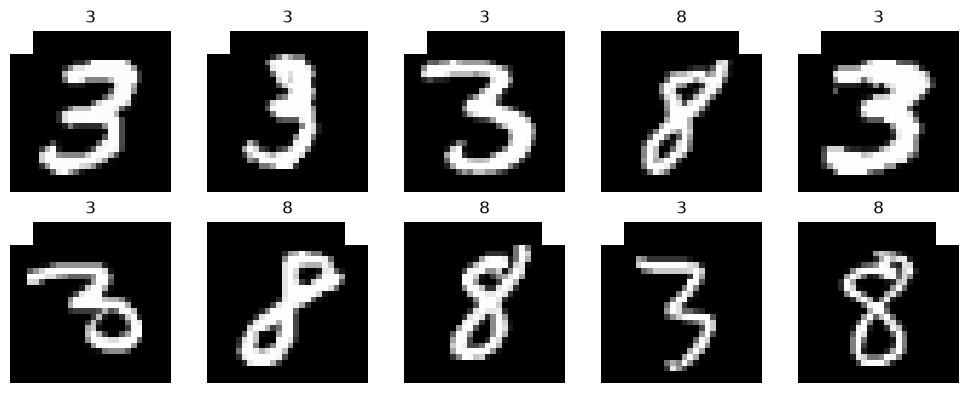

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), X_train[:10], y_train[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Lessons Learned

As we will continue to see throughout the course, even performing seemingly simple tasks with AI tools can come with risks. For more difficult tasks, some challenges to reliable AI deployment in the real world are just beginning to be addressed as the AI field matures. The fields of AI engineering, AI explainability, and best practices for resilient AI deployment will continue to evolve, much in the same way the fields of software engineering, cybersecurity, and other disciplines evolved best practices as they matured over decades. This course will present a snapshot of some of the most important current best practices evolving in the AI field. By the end of this course, students will be able to spot common issues and risks in existing AI systems, and grasp the basic principles needed to design a *resilient* AI system from the ground up.